https://github.com/hwantajee
## SVM (Support Vector Machine)를 활용한 붓꽃 품종 분류

In [1]:
from sklearn.datasets import load_iris

In [2]:
iris = load_iris()
# print(iris.DESCR)

In [3]:
data = iris.data
label = iris.target

print(data.shape)
print(label.shape)

(150, 4)
(150,)


In [4]:
iris_names = iris.target_names
print(iris_names)

['setosa' 'versicolor' 'virginica']


In [5]:
from sklearn.model_selection import train_test_split

In [6]:
train_data, test_data, train_label, test_label = train_test_split(data, label, test_size=0.3, random_state=0)

In [7]:
from sklearn.svm import SVC

In [8]:
svc = SVC()
model = svc.fit(train_data, train_label)
print(model.score(train_data, train_label))
print(model.score(test_data, test_label))

0.9714285714285714
0.9777777777777777


In [9]:
from sklearn import metrics
predict = model.predict(test_data)
score = metrics.accuracy_score(test_label, predict)
print(score)

0.9777777777777777


In [10]:
predict = model.predict([[5.7, 2.8, 10.0, 4.5]])
print(iris_names[predict])

['virginica']


In [11]:
import numpy as np
import matplotlib.pyplot as plt

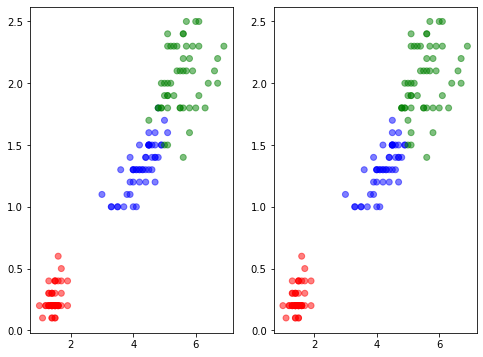

In [15]:
fig = plt.figure(figsize = (8, 6))
color = np.array(["red", "blue", "green"])
ax1 = fig.add_subplot(1, 2, 1)
ax1.scatter(data[:, 2], data[:, 3], color=color[label], alpha=0.5)

predicts = model.predict(data)
ax2 = fig.add_subplot(1, 2, 2)
ax2.scatter(data[:, 2], data[:, 3], color=color[predicts], alpha=0.5)
plt.show()

## K-Fold Cross Validation (K분할 교차검증)

In [16]:
from sklearn.model_selection import cross_val_score

In [17]:
scores = cross_val_score(svc, data, label, cv=3)
print(scores)
print(scores.mean())

[0.96 0.98 0.94]
0.96


#### 모델 최적화

In [19]:
from sklearn.model_selection import GridSearchCV

In [20]:
params = [
    {"C": [1, 10, 100, 1000], "kernel": ["linear"]},
    {"C": [1, 10, 100, 1000], "kernel": ["rbf"], "gamma": [0.001, 0.0001]}
    ]

In [21]:
gs = GridSearchCV(SVC(), params, n_jobs=1)
model = gs.fit(data, label)
print(model.best_score_)
print(model.best_params_)
print(model.best_estimator_)

0.9800000000000001
{'C': 1, 'kernel': 'linear'}
SVC(C=1, kernel='linear')


In [22]:
best_model = model.best_estimator_
predict = best_model.predict([[4.7, 5.5, 10.5, 4.5]])
print(iris_names[predict])
print(best_model.score(train_data, train_label))
print(best_model.score(test_data, test_label))

['virginica']
1.0
0.9777777777777777
